# DS2LSOM – Evaluation on Digits Dataset

Evaluates clustering quality using Rand index and Jaccard index (same metrics as in the paper).


In [12]:
import time

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from ds2l_som.ds2lsom import DS2LSOM
from dbgsom.SomVQ import SomVQ

## Data


In [13]:
digits = load_digits()
X = StandardScaler().fit_transform(digits.data)
y = digits.target
print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}, Classes: {len(set(y))}")

Samples: 1797, Features: 64, Classes: 10


In [14]:
som = SomVQ(sigma_end=1)


In [15]:
som.fit(X)

,sigma_end,1
,n_iter,500
,spreading_factor,0.5
,sigma_start,None
,sigma_fine,None
,vertical_growth,False
,decay_function,'exponential'
,neighborhood_function,'gaussian'
,verbose,False
,coarse_training_frac,0.5
,random_state,None


In [16]:
print(som.quantization_error_)
print(som.topographic_error_)

5.584037514802416
0.06399554813578186


## Train


In [19]:
model = DS2LSOM(
    n_prototypes=100,
    threshold=10,
    method="som",
    model_args={
        "init": {"sigma_end": 1.0, "random_state": 42, "spreading_factor": 0.9}
    },
)

t0 = time.perf_counter()
model.fit(X)
labels = model.predict(X)
elapsed = time.perf_counter() - t0

n_found = len(set(labels[labels >= 0]))
n_noise = (labels == -1).sum()
print(f"Runtime:          {elapsed:.1f}s")
print(f"Clusters found:   {n_found}  (expected: {len(set(y))})")
print(f"Unassigned points: {n_noise}")

Runtime:          0.3s
Clusters found:   12  (expected: 10)
Unassigned points: 167


## Metrics


In [20]:
from sklearn.metrics import pair_confusion_matrix

mask = labels >= 0
tn, fp, fn, tp = pair_confusion_matrix(y[mask], labels[mask]).ravel()
rand = (tp + tn) / (tp + tn + fp + fn)
jaccard = tp / (tp + fp + fn)
print(f"Rand Index:    {rand:.3f}")
print(f"Jaccard Index: {jaccard:.3f}")

Rand Index:    0.933
Jaccard Index: 0.506


## Visualization

t-SNE projection: true labels (left) vs. predicted clusters (right).


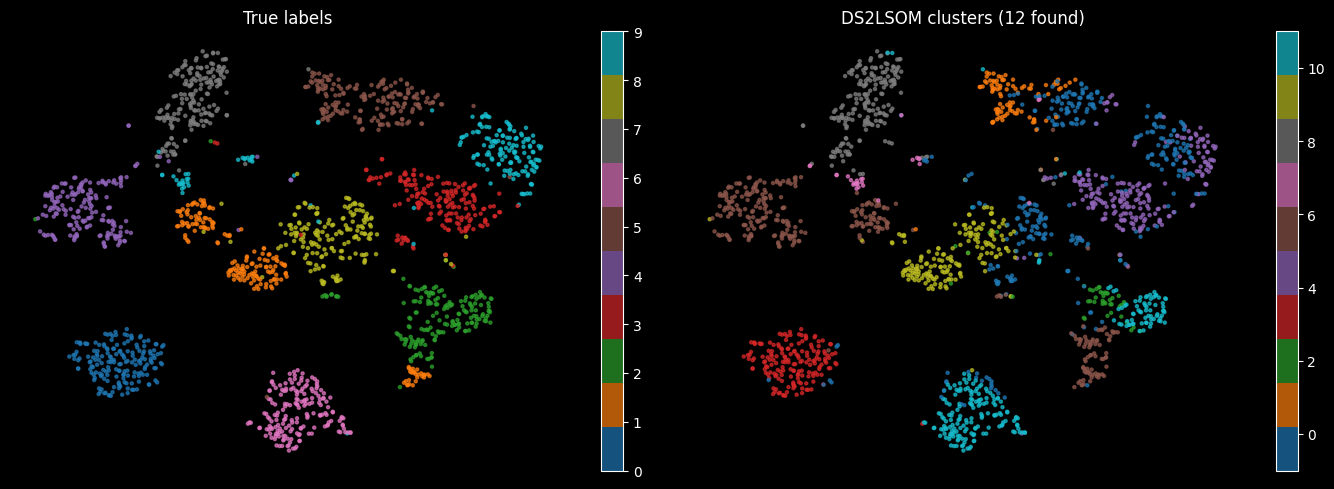

In [21]:
embedding = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(embedding[:, 0], embedding[:, 1], c=y, cmap="tab10", s=5, alpha=0.7)
axes[0].set_title("True labels")
axes[0].axis("off")
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10", s=5, alpha=0.7)
axes[1].set_title(f"DS2LSOM clusters ({n_found} found)")
axes[1].axis("off")
plt.colorbar(sc1, ax=axes[1])

plt.tight_layout()
plt.show()

## Cluster composition

Heatmap showing which true digit classes land in which cluster (purity check).


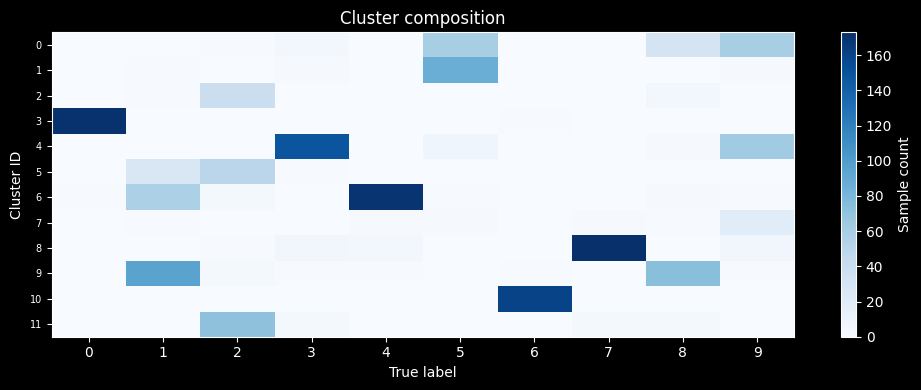

In [22]:
cluster_ids = sorted(set(labels[mask]))
true_classes = sorted(set(y))

matrix = np.zeros((len(cluster_ids), len(true_classes)), dtype=int)
for i, cid in enumerate(cluster_ids):
    for j, cls in enumerate(true_classes):
        matrix[i, j] = ((labels == cid) & (y == cls)).sum()

fig, ax = plt.subplots(figsize=(10, max(4, len(cluster_ids) // 3)))
im = ax.imshow(matrix, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(true_classes)))
ax.set_xticklabels(true_classes)
ax.set_yticks(range(len(cluster_ids)))
ax.set_yticklabels(cluster_ids, fontsize=7)
ax.set_xlabel("True label")
ax.set_ylabel("Cluster ID")
ax.set_title("Cluster composition")
plt.colorbar(im, ax=ax, label="Sample count")
plt.tight_layout()
plt.show()